# Global Air Pollution Analysis
## CS316: Introduction to AI and Data Science Project

This notebook presents a complete data science pipeline for predicting urban air quality levels using the Global Air Pollution Dataset. The objective is to accurately predict the overall Air Quality Index (AQI) value of a city from its individual pollutant readings (CO, Ozone, NO2, PM2.5), identify the key pollutants driving poor air quality, and derive insights that contribute to healthier urban environments.

**SDG Alignment:** SDG 3 (Good Health and Well-Being) and SDG 11 (Sustainable Cities and Communities)

---
## Step 1: Import Require Libraries

We import the essential Python libraries.

In [47]:
import pandas as pd 
import numpy as  np
import matplotlib.pyplot as  plt
import seaborn as sns
%matplotlib inline
%pip install scikit-learn
import  joblib
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import  train_test_split
#the required imports 


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


---
## Step 2: Load the Dataset

We load the Global Air Pollution Dataset from a CSV file.

In [48]:
df=pd.read_csv( 'global_air_pollution_dataset.csv') #loading the dataset
print( "Dataset shape:") 
df.shape #checking how many rows and columns

Dataset shape:


(23463, 12)

---
## Step 3: Initial Data Exploration

### 3.1 View First Few Records

In [49]:
print( "First 5 records of the dataset:" )
df.head( ) #checking the first 5 records 

First 5 records of the dataset:


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


### 3.2 View Last Few Records

In [50]:
print( "Last 5 records of the dataset:")
df.tail()#checking the last 5 records 

Last 5 records of the dataset:


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
23458,India,Gursahaiganj,184,Unhealthy,3,Good,154,Unhealthy,2,Good,184,Unhealthy
23459,France,Sceaux,50,Good,1,Good,20,Good,5,Good,50,Good
23460,India,Mormugao,50,Good,1,Good,22,Good,1,Good,50,Good
23461,United States of America,Westerville,71,Moderate,1,Good,44,Good,2,Good,71,Moderate
23462,Malaysia,Marang,70,Moderate,1,Good,38,Good,0,Good,70,Moderate


### 3.3 Check for Duplicate Records

In [51]:
duplicate_count=df.duplicated().sum()
print("Number of duplicate records:" )
print( duplicate_count)#checking for duplicate records

Number of duplicate records:
0


### 3.4 Dataset Shape and Dimensions

In [52]:
print(f"Dataset shape:{df.shape}" ) #full shape of the dataset 
print(f"Number of rows:{df.shape[0]}") #rows of the dataset
print( f"Number of columns:{df.shape[1]}")#columns of the dataset

Dataset shape:(23463, 12)
Number of rows:23463
Number of columns:12


### 3.5 Data Types and Info

In [53]:
df.info()#information about the dataset 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


### 3.6 Descriptive Statistics

In [54]:
print( "Descriptive Statistics:" )
df.describe()#descriptive statistics for the dataset

Descriptive Statistics:


,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


---
## Step 4: Data Cleaning and Preprocessing

### 4.1 Check for Missing Values

In [55]:
print( "Missing values in each column:" )
df.isnull().sum( ) #cheching the dataset for missing values

Missing values in each column:


Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64

### 4.2  Drop irrelevant Columns

We didnt fill the missing country and city columns because it would be better if we completely dropped city and country.We drop `City` because it has too many unique values (23,462) and `Country` as geographic labels dont directly determine air quality. Cities within the same country can have vastly different pollution levels.
We also drop `CO AQI Category` and `NO2 AQI Category` as over 99.9% of their values are 'Good' making them uninformative for the model.

In [56]:
df =df.drop( columns=['City','Country','CO AQI Category','NO2 AQI Category'])#drop irrelevant rows
print("Remaining columns:")
print(df.columns.tolist())#turning the columns into a list to print

print(f"\nDataset shape:{df.shape}")#shape of the new dataset

Remaining columns:
['AQI Value', 'AQI Category', 'CO AQI Value', 'Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value', 'PM2.5 AQI Value', 'PM2.5 AQI Category']

Dataset shape:(23463, 8)


### 4.3 One-Hot Encoding of Categorical Columns

We convert the remaining categorical AQI category columns into numeric format using one-hot encoding so they can be used by machine learning models.

In [ ]:
categorical_cols=['Ozone AQI Category','PM2.5 AQI Category']#taking categorical columns
df= pd.get_dummies( df,columns=categorical_cols)#applying one hot encodint 

### 4.4 Outlier Detection

We used the IQR method to detect outliers in the numerical AQI columns.The outliers detected represent extreme pollution events in certain cities. the outliers are the most critical cases for our SDG goals as the "hazardous" cities are the ones twhere intervention is most needed.

In [90]:
#checking for outliers using IQR method
numerical_cols =['AQI Value','CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']#taking the numerical columns
print("Outlier Detection using IQR Method:")
for col in numerical_cols:
    Q1=df[col].quantile(0.25) #lower quartile calculation
    Q3=df[col].quantile(0.75) #upper quartile calculation
    IQR=Q3-Q1#interquartile range calculation
    lower=Q1-1.5*IQR #minimum calculation
    upper=Q3 +1.5* IQR#maximum calculation
    outliers=df[(df[col]< lower) | (df[col]> upper) ]#outlier detection
    print(f"{col}: {len(outliers)} outliers ")

Outlier Detection using IQR Method:
AQI Value: 893 outliers 
CO AQI Value: 1251 outliers 
Ozone AQI Value: 1329 outliers 
NO2 AQI Value: 1236 outliers 
PM2.5 AQI Value: 806 outliers 


### 4.5 Checking dataset after hot encodind
After one-hot encoding, 6,363 rows became identical due to reduced feature dimensionality. These redundant rows were removed.

In [ ]:
duplicate_count=df.duplicated().sum() #number of duplicate values after hot encoding
print("Number of duplicate records:" )
print(duplicate_count)
df = df.drop_duplicates()#remove duplicate records
print(f"Dataset shape after removing duplicates: {df.shape}")#shape after duplicates removal

Number of duplicate records:
6363
Dataset shape after removing duplicates: (17100, 17)


---
## Step 5: Exploratory Data Analysis (EDA)

### 5.1 AQI Category Distribution (Bar Chart)

We analyze the distribution of the overall AQI category to understand how cities across the dataset are spread between Good, Moderate, and the various Unhealthy levels.

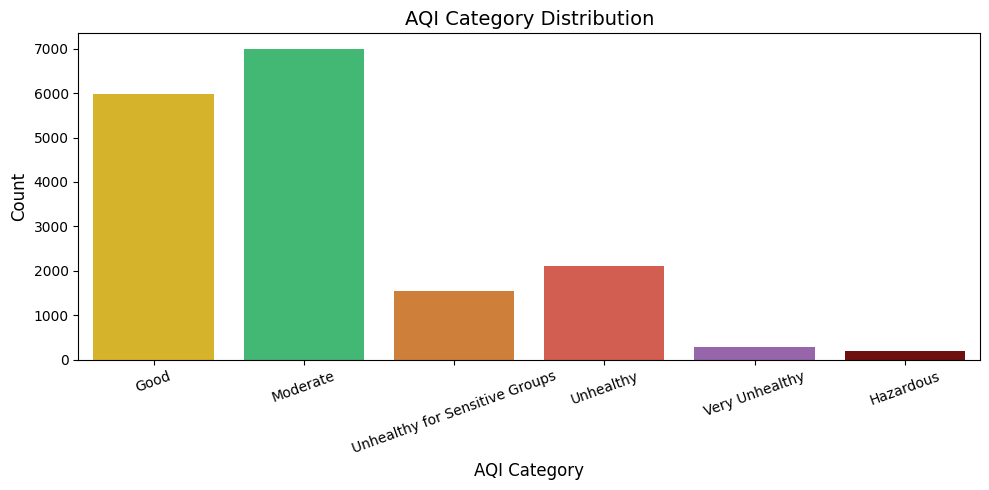


Value counts for AQI Category:
AQI Category
Moderate                          6995
Good                              5979
Unhealthy                         2109
Unhealthy for Sensitive Groups    1547
Very Unhealthy                     286
Hazardous                          184
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(10,5))#figure size for better readability
plt.title('AQI Category Distribution', fontsize=14)

order = ['Good','Moderate','Unhealthy for Sensitive Groups','Unhealthy','Very Unhealthy','Hazardous']#order for the AQI categories from least to most severe
colors = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#9b59b6','#7f0000'] # distinct colors for the bars->gives visual clarity
sns.countplot(x='AQI Category', data=df, order=order, hue='AQI Category', palette=colors)
plt.xlabel('AQI Category',fontsize=12)
plt.ylabel('Count',fontsize=12)
plt.xticks(rotation=20,fontsize=10)#rotate labels so they dont overlap
plt.tight_layout()
plt.show()

print( "\nValue counts for AQI Category:") 
print(df['AQI Category' ].value_counts())#print the count for each AQI category



### 5.2 Distribution of AQI Values (Histogram)

We examine the distribution of the overall AQI value across all cities.

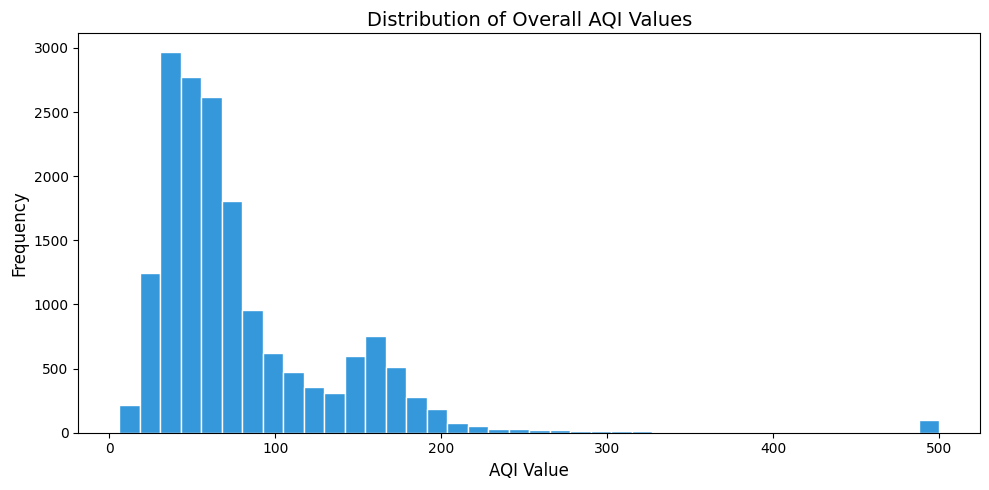

Mean AQI: 80.81
Median AQI: 61.00
Std AQI: 61.32


In [ ]:
plt.figure(figsize=(10,5))#figure size for readability
plt.title('Distribution of Overall AQI Values ', fontsize=14)
plt.hist( df['AQI Value'] ,bins=40,color='#3498db ',edgecolor='white')#histogram with 80 bins to show the distribution shape
plt.xlabel('AQI Value',fontsize=12)
plt.ylabel('Frequency',fontsize=12)
plt.tight_layout()
plt.show()

print(f"Mean AQI:{df['AQI Value'].mean():.2f}")#descriptive statistics for the aqi
print(f"Median AQI: {df['AQI Value'].median():.2f}")
print(f"Std AQI: {df['AQI Value'].std():.2f}")

### 5.3 Per-Pollutant AQI Distribution (Box Plots)

We compare the distribution of each pollutant AQI value to understand which pollutants contribute most to poor air quality.

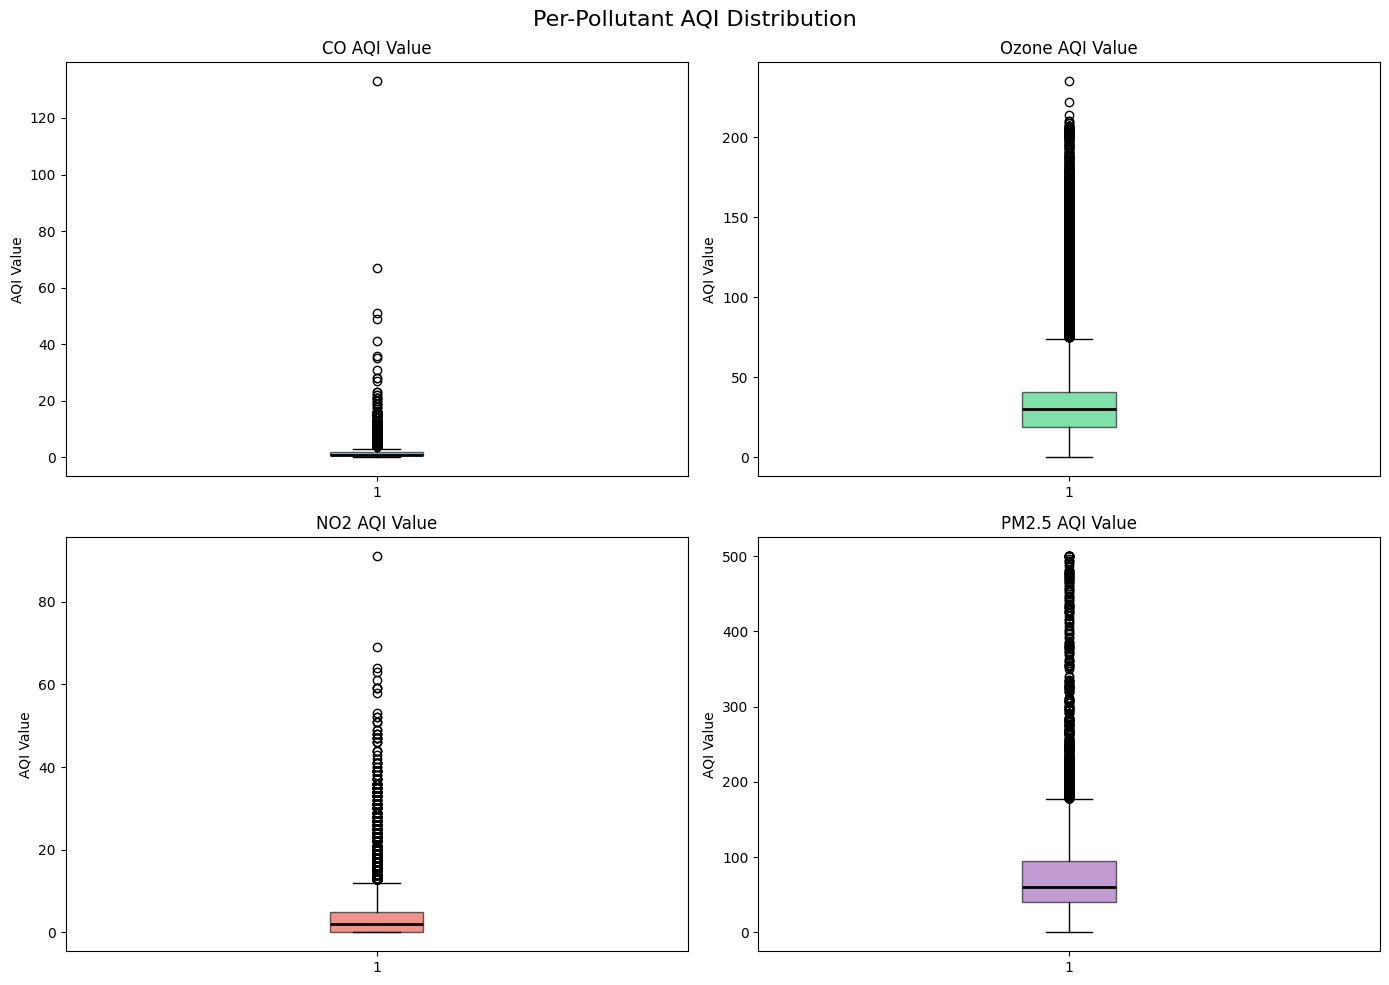

In [ ]:
fig,axes=plt.subplots(2,2,figsize=(14 ,10) )#figure size for readability
fig.suptitle('Per-Pollutant AQI Distribution',fontsize=16)

pollutants=['CO AQI Value','Ozone AQI Value' ,'NO2 AQI Value','PM2.5 AQI Value']
colors = ['#3498db','#2ecc71','#e74c3c', '#9b59b6']

for ax,col,color in zip(axes.flatten(),pollutants,colors):#converts the 2x2 grid into a flat list of 4 axes for easy iteration
    ax.boxplot(df[col],patch_artist=True,#patch_artist=True allows the box to be filled with color
               boxprops=dict(facecolor=color,alpha=0.6),medianprops=dict(color='black',linewidth=2))
    ax.set_title( col,fontsize=12)
    ax.set_ylabel('AQI Value',fontsize=10)

plt.tight_layout()
plt.show()



PM2.5 has the widest spread and the most extreme outliers among all pollutants, confirming its dominant role in driving overall AQI values. CO and NO2 are concentrated at very low values across most cities, while Ozone shows moderate variability.

### 5.4 PM2.5 vs Overall AQI (Scatter Plot)

We examine the relationship between PM2.5 AQI value and the overall AQI value.

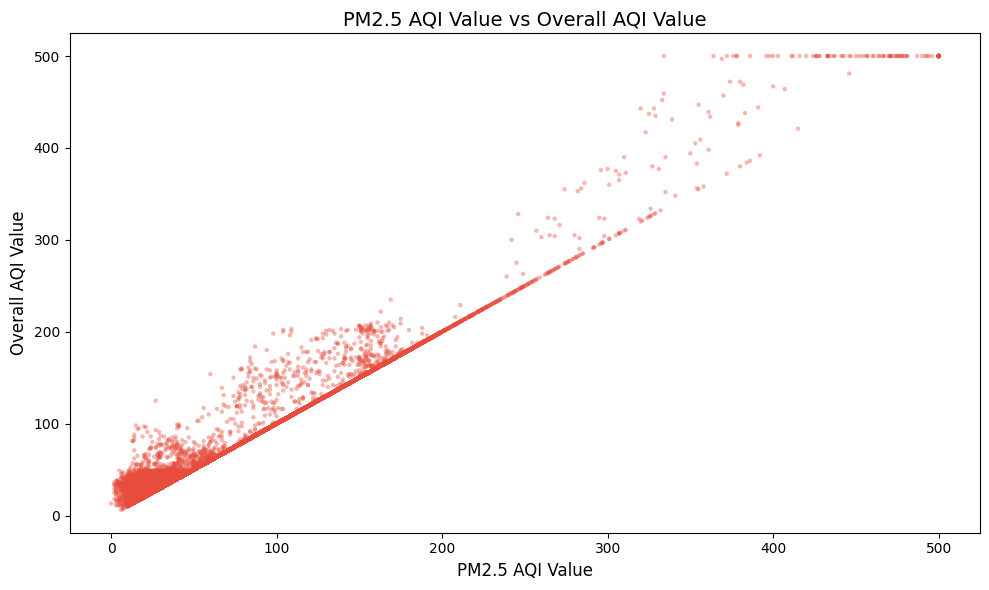

Correlation between PM2.5 AQI and Overall AQI: 0.984


In [ ]:
plt.figure(figsize=(10,6))# figure size for readability
plt.title('PM2.5 AQI Value vs Overall AQI Value',fontsize=14)
plt.scatter(df['PM2.5 AQI Value'], df['AQI Value'], alpha=0.4,color='#e74c3c',edgecolors='none', s=10)#Plot a scatter plot to visualize the relationship between PM2.5 and overall AQI
plt.xlabel('PM2.5 AQI Value',fontsize=12)

plt.ylabel(' Overall AQI Value', fontsize=12)
plt.tight_layout()
plt.show()

correlation=df['PM2.5 AQI Value'].corr(df['AQI Value'] )#compute the Pearson correlation coefficient between PM2.5 and overall AQI
print( f"Correlation between PM2.5 AQI and Overall AQI: { correlation:.3f}")


a near-perfect positive correlation (r = 0.984) between PM2.5 AQI and the overall AQI value. This confirms that PM2.5 is the dominant pollutant driving air quality classifications globally.

### 5.5 Correlation Heatmap

We examine the correlations between all numerical features to identify relationships and potential multicollinearity.

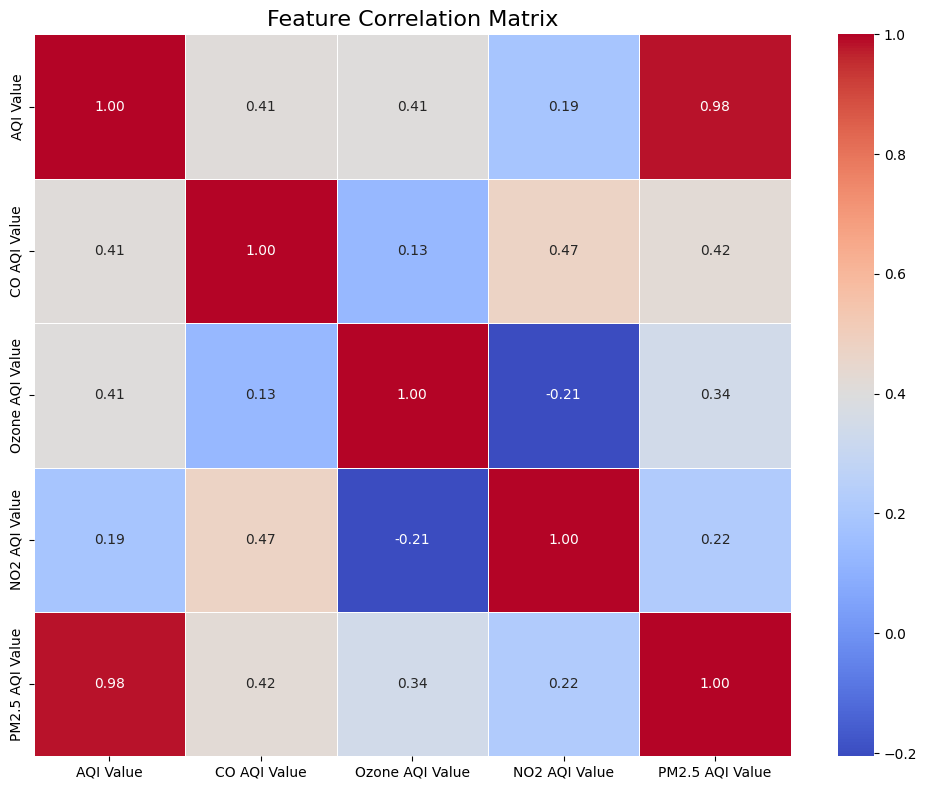

In [ ]:
numerical_cols=['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']#select only the original numerical columns for correlation analysis


plt.figure(figsize=( 10,8))#size for readability
sns.heatmap(df[ numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)#plot a heatmap of the correlation matrix
plt.title(' Feature Correlation Matrix', fontsize=16)

plt.tight_layout()
plt.show()


PM2.5 shows an extremely strong correlation with the overall AQI (0.98). CO and Ozone show moderate correlations with the overall AQI, while NO2 shows a weaker relationship. The low correlations between pollutants themselves suggest that each pollutant provides independent information.

### 5.6 Pairplot

We visualize the relationships between all numerical variables, colored by AQI category.

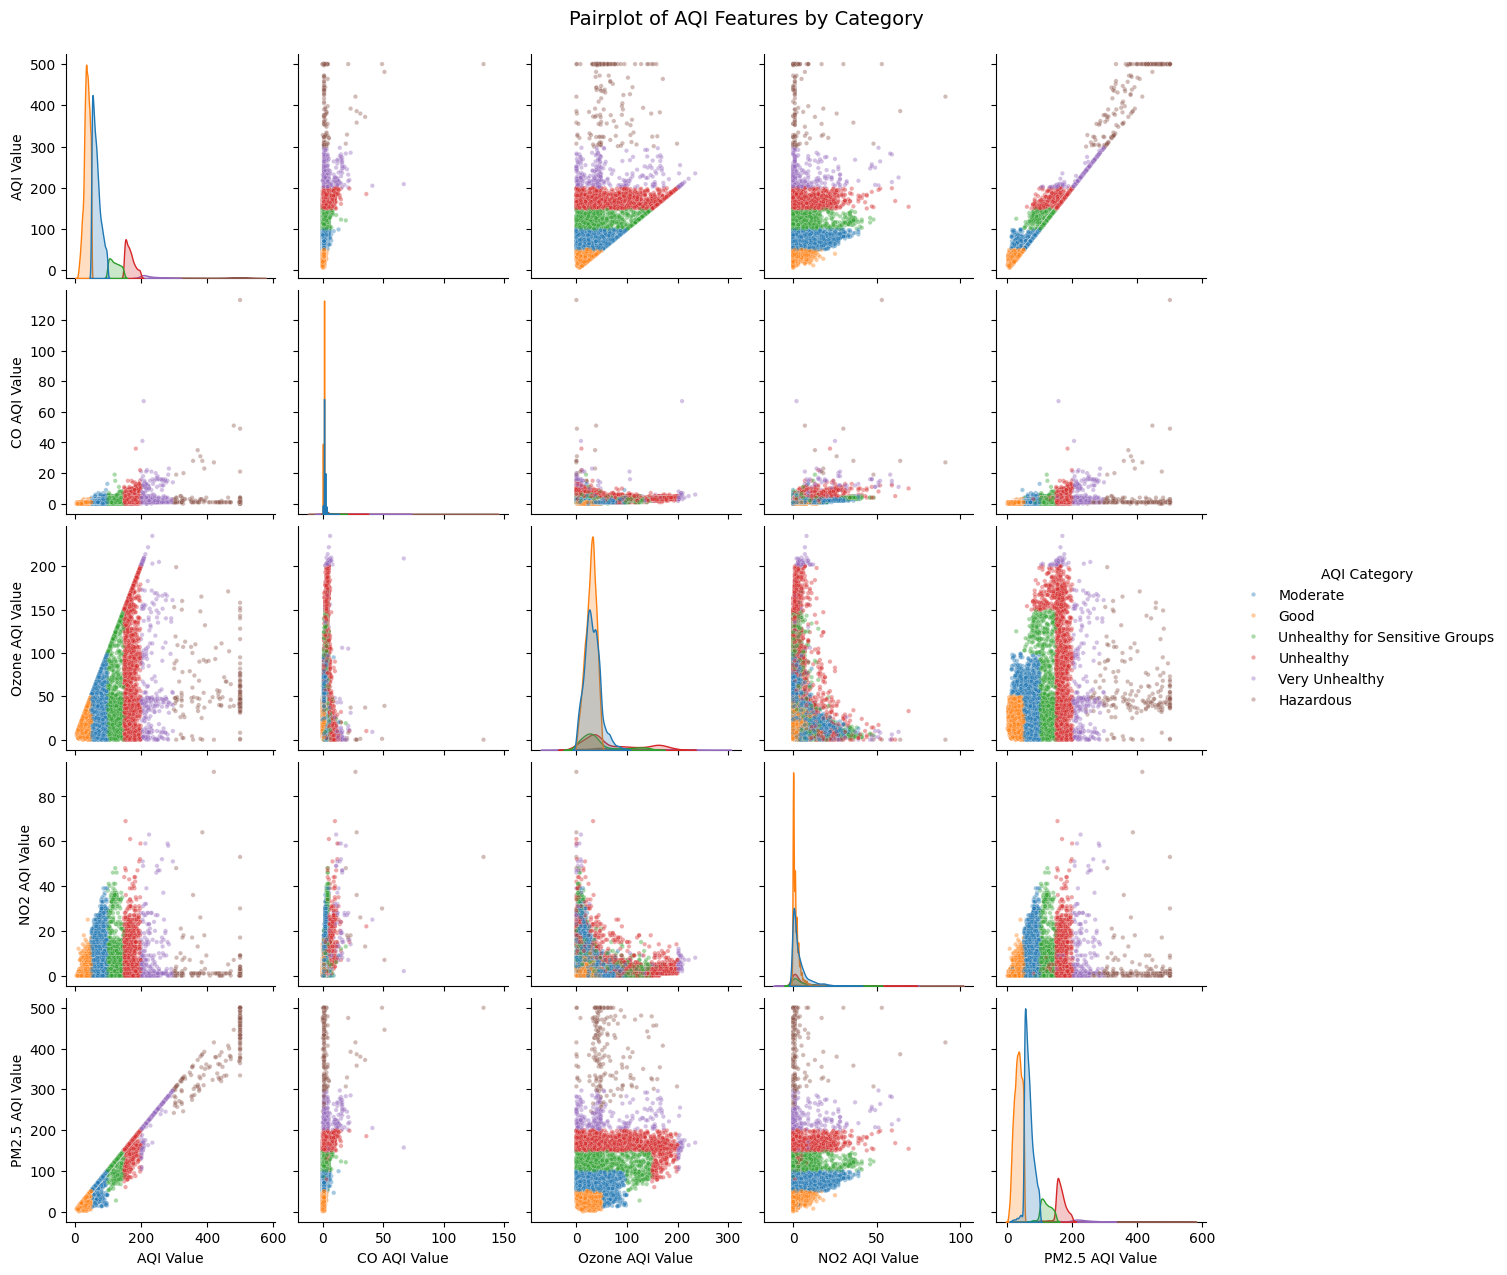

In [ ]:
pairplot_cols=['AQI Value','CO AQI Value','Ozone AQI Value','NO2 AQI Value' ,'PM2.5 AQI Value','AQI Category' ]#columns to include in the pairplot


df_original =pd.read_csv( 'global_air_pollution_dataset.csv' ).dropna()#we need to check it before the one-hot encoding for pairplot
sns.pairplot( df_original[ pairplot_cols], hue='AQI Category' ,plot_kws={'alpha':0.4 ,'s': 10})#plot a pairplot showing relationships between all numerical features
plt.suptitle('Pairplot of AQI Features by Category',y=1.02,fontsize=14)
plt.show()


The pairplot reveals clear separation between AQI categories, particularly along the PM2.5 axis. Cities labeled 'Hazardous' and 'Very Unhealthy' cluster at high PM2.5 values, while 'Good' cities cluster at the lower end. This confirms that PM2.5 is the most influential feature for predicting overall AQI.

### 5.7 Violin Plot — AQI Value Distribution by Category

The violin plot shows the full distribution shape of AQI values within each category.

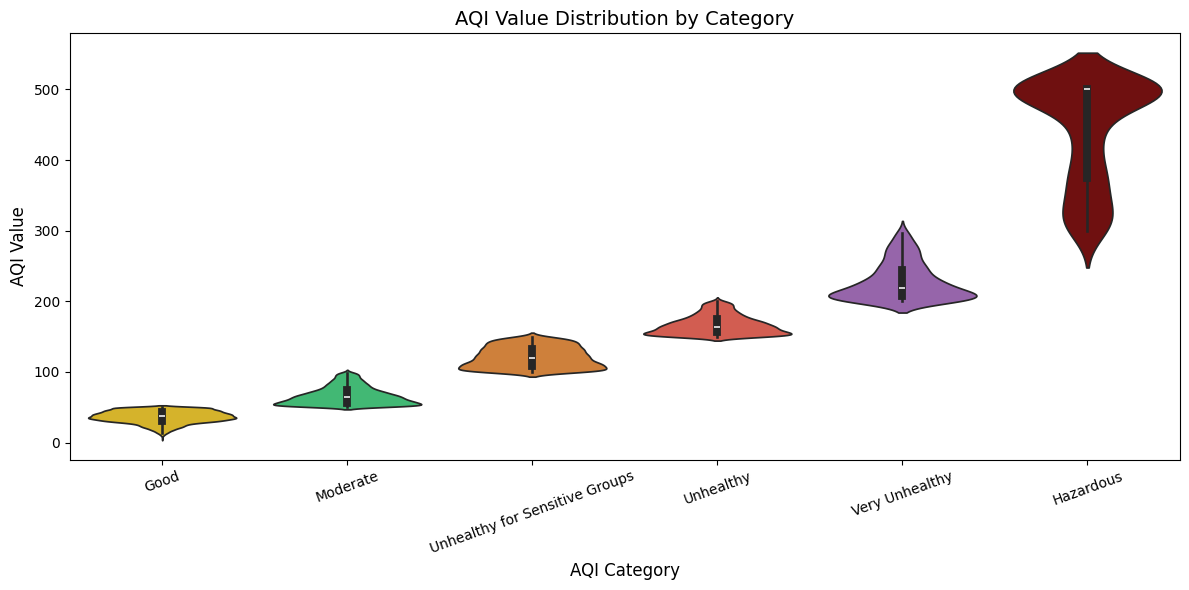

In [ ]:
plt.figure(figsize =(12,6))#figure size for readability
plt.title('AQI Value Distribution by Category', fontsize=14)
order = ['Good','Moderate','Unhealthy for Sensitive Groups','Unhealthy','Very Unhealthy','Hazardous']#order from least to most severe
sns.violinplot(x ='AQI Category',y='AQI Value' ,data=df_original,order=order,#a violin plot showing the full distribution shape of AQI values
               hue='AQI Category',palette=['#2ecc71','#f1c40f','#e67e22', '#e74c3c', '#9b59b6', '#7f0000'],
               legend= False)

plt.xlabel('AQI Category',fontsize =12)
plt.ylabel('AQI Value',fontsize=12)
plt.xticks(rotation=20,fontsize= 10)#rotate x-axis labels  to prevent overlap
plt.tight_layout( )
plt.show()



The violin plot confirms that AQI categories are well-separated with minimal overlap, indicating that the relationship between pollutants and AQI Value should be tractable for machine learning models to learn. The 'Hazardous' category shows the widest spread, reflecting the variability of extreme pollution events.

### 5.8 Group Statistics by AQI Category

We compute the mean pollutant values for each AQI category to understand how each pollutant contributes to different levels of air quality.

In [ ]:


group_cols=['AQI Category','AQI Value','CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value','PM2.5 AQI Value']
grouped =df_original[ group_cols ].groupby( 'AQI Category' ).mean()#group the data by AQI Category and compute the mean of each pollutant per category

print("Mean Pollutant Values by AQI Category:")

print(grouped.round(2))#2 decimal places for cleaner output


Mean Pollutant Values by AQI Category:
                                AQI Value  CO AQI Value  Ozone AQI Value  \
AQI Category                                                               
Good                                36.51          0.77            28.26   
Hazardous                          440.94          3.74            58.49   
Moderate                            66.46          1.30            31.24   
Unhealthy                          166.73          3.09            69.04   
Unhealthy for Sensitive Groups     121.20          2.15            41.90   
Very Unhealthy                     228.17          5.24            84.56   

                                NO2 AQI Value  PM2.5 AQI Value  
AQI Category                                                    
Good                                     1.48            31.67  
Hazardous                                3.76           400.20  
Moderate                                 3.65            65.47  
Unhealthy                  

---
## Step 6: Data Investigation — Answering Key Questions

Beyond visualizing the data, we now ask and answer specific investigative questions to derive deeper insights from the dataset.

### Question 1: Which pollutant has the strongest relationship with overall AQI?

We compute the correlation of each pollutant with the overall AQI Value to identify which one drives air quality the most.

In [ ]:
pollutant_cols=['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']#  the four pollutant columns to test against overall AQI
correlations = df[pollutant_cols].corrwith(df['AQI Value']).sort_values(ascending=False)# correlation of each pollutant with the overall AQI Value
print("Correlation of each pollutant with Overall AQI Value:")
print(correlations.round(4))

Correlation of each pollutant with Overall AQI Value:
PM2.5 AQI Value    0.9845
CO AQI Value       0.4110
Ozone AQI Value    0.4066
NO2 AQI Value      0.1899
dtype: float64


**Finding:** PM2.5 shows by far the strongest correlation with overall AQI, confirming it is the dominant pollutant influencing air quality globally. This finding is consistent with established environmental science literature.

### Question 2: What percentage of cities worldwide have unsafe air quality?

An AQI value above 100 is considered unhealthy for sensitive groups. We calculate what proportion of cities in the dataset exceed this threshold.

Percentage of cities with UNSAFE air quality (AQI > 100): 23.85%
Percentage of cities with SAFE air quality (AQI <= 100): 76.15%


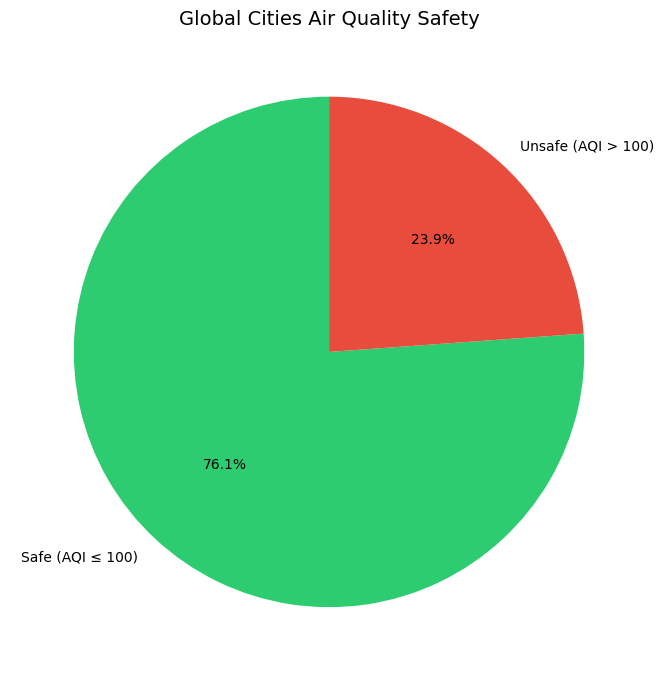

In [ ]:
unsafe=(df['AQI Value']>100).mean() *100#calculate percentage of cities with AQI above 100(unsafe threshold)
safe=100- unsafe#safe percentage
print(f"Percentage of cities with UNSAFE air quality (AQI > 100): {unsafe:.2f}%")
print(f"Percentage of cities with SAFE air quality (AQI <= 100): {safe:.2f}%")

plt.figure(figsize=(7, 7))
plt.pie([safe,unsafe],#visualize with pie chart
        labels =['Safe (AQI ≤ 100)', 'Unsafe (AQI > 100)'],
        colors=['#2ecc71', '#e74c3c'],
        autopct='%1.1f%%',
        startangle= 90)
plt.title('Global Cities Air Quality Safety ' ,fontsize =14)
plt.tight_layout()
plt.show()


**Finding:** A significant portion of cities worldwide have AQI values above 100, indicating that air pollution is a widespread global health concern rather than an isolated regional problem.

### Question 3: Do Ozone and PM2.5 tend to rise together, or independently?

We examine the relationship between Ozone and PM2.5 to understand whether these two pollutants are correlated or behave independently across cities.

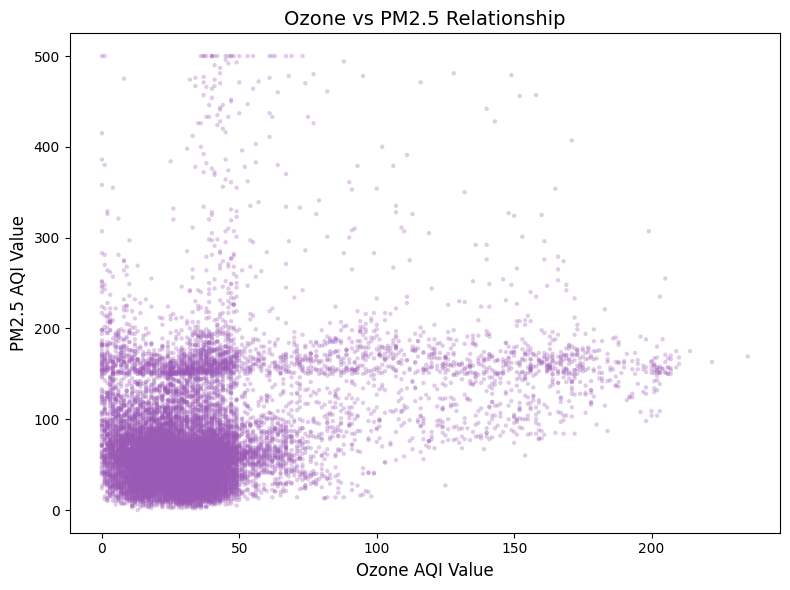

Correlation between Ozone and PM2.5: 0.3414


In [ ]:

plt.figure(figsize=(8,6))
plt.scatter(df['Ozone AQI Value'] ,df['PM2.5 AQI Value'],alpha=0.3,color='#9b59b6' ,edgecolors='none',s=10)#scatter plot of Ozone vs PM2.5
plt.xlabel('Ozone AQI Value',fontsize=12)
plt.ylabel('PM2.5 AQI Value',fontsize=12)
plt.title('Ozone vs PM2.5 Relationship', fontsize=14)
plt.tight_layout()
plt.show()
ozone_pm25_corr =df['Ozone AQI Value'].corr(df['PM2.5 AQI Value'])
print(f" Correlation between Ozone and PM2.5:{ozone_pm25_corr:.4f}")


**Finding:** The correlation between Ozone and PM2.5 is moderate, meaning they do not consistently rise together. This suggests they are driven by different pollution sources — PM2.5 is primarily linked to combustion and industrial activity, while Ozone is formed through photochemical reactions involving sunlight.

### Question 4: At what average PM2.5 level does air quality become hazardous?

We compute the average PM2.5 AQI value for each AQI category to identify the PM2.5 thresholds that correspond to different levels of air quality severity.

Average PM2.5 AQI Value per AQI Category:
AQI Category
Good                               31.67
Moderate                           65.47
Unhealthy for Sensitive Groups    118.33
Unhealthy                         162.71
Very Unhealthy                    219.07
Hazardous                         400.20
Name: PM2.5 AQI Value, dtype: float64


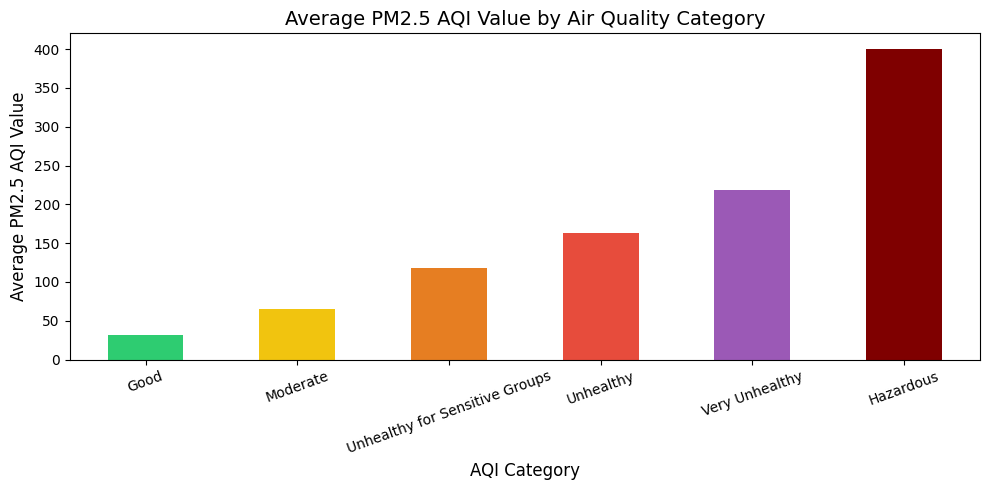

In [100]:

# Reload original df for this analysis (before one-hot encoding)
df_original_q4 = pd.read_csv('global_air_pollution_dataset.csv').dropna()#reload original df for this analysis(before one-hot encoding)

# Mean PM2.5 per AQI category
order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']#order from least to most severe
pm25_by_cat = df_original_q4.groupby('AQI Category')['PM2.5 AQI Value'].mean().reindex(order)#group by AQI category and compute the mean PM2.5 AQI value per category

print("Average PM2.5 AQI Value per AQI Category:")

print(pm25_by_cat.round(2))
pm25_by_cat.plot(kind='bar',color=['#2ecc71','#f1c40f','#e67e22','#e74c3c','#9b59b6','#7f0000'],figsize=(10, 5))#bar chart showing average PM2.5 per AQI category
plt.title('Average PM2.5 AQI Value by Air Quality Category', fontsize=14)
plt.xlabel('AQI Category', fontsize=12)
plt.ylabel('Average PM2.5 AQI Value', fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Finding:** There is a clear and dramatic escalation in PM2.5 values as air quality worsens. Cities classified as Hazardous have an average PM2.5 AQI of over 400, compared to just ~32 for Good cities. This confirms PM2.5 as the primary threshold pollutant for air quality classification.

---
## Step 7: Prepare Data for Modeling

We separate features and the target variable. We use the four pollutant AQI values (CO, Ozone, NO2, PM2.5) as features to predict the overall AQI Value. We exclude the AQI Category column as it is derived directly from AQI Value and would cause data leakage.

In [ ]:
X = df[['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']]#the four pollutant columns as features
y = df['AQI Value'] #target variable we are trying to predict

print(f"Features used: {X.columns.tolist()}")
print(f"Features shape: {X.shape}")
print(f"Target shape:{y.shape}")
print(f"Target (AQI Value) statistics:")
print( y.describe().round(2))#descriptive statistics for the target

Features used: ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
Features shape: (17100, 4)
Target shape: (17100,)
Target (AQI Value) statistics:
count    17100.00
mean        80.81
std         61.32
min          6.00
25%         43.00
50%         61.00
75%         97.00
max        500.00
Name: AQI Value, dtype: float64


---
## Step 8: Linear Regression Model

We use Linear Regression as our baseline model to predict the overall AQI Value from the four pollutant readings. Linear Regression is the natural starting point for a continuous prediction task — it attempts to find the best linear relationship between the input features and the target variable.

First, we split the dataset into training (80%) and testing (20%) sets. The training set is used to fit the model, and the testing set is used to evaluate how well it generalises to unseen data.

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42 )#80% training 20% testing, random_state for reproducibility
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (13680, 4)
Test shape: (3420, 4)


Next, we scale the features using StandardScaler so that all pollutant values are on the same scale. This helps the model converge more reliably. We then train the Linear Regression model on the scaled training data.

In [ ]:
scaler=StandardScaler()#standardize features to the same scale
X_train_scaled =scaler.fit_transform(X_train ) #fit on training data
X_test_scaled=scaler.transform(X_test)#apply the same scaling to test data
lr_model = LinearRegression()#initialize the lr model
lr_model.fit( X_train_scaled, y_train)#train the model on the scaled training data

print("Model trained successfully.")

Model trained successfully.


After training, we use the model to predict AQI values on the test set. These predicted values will then be compared with the actual AQI values to evaluate performance.

In [ ]:
y_pred_lr =lr_model.predict( X_test_scaled)#predict AQI values on the test set

print("Predictions completed." )
print(f"Sample predictions: {y_pred_lr[:5].round(2)}")#first 5 predictions
print(f"Actual values:{y_test[:5].values}")#first 5 actual values for comparison

Predictions completed.
Sample predictions: [27.35 42.39 69.02 53.62 36.81]
Actual values:      [37 41 65 53 34]


We evaluate the model using three standard regression metrics:
- **MAE (Mean Absolute Error):** average absolute difference between predicted and actual AQI values
- **RMSE (Root Mean Squared Error):** penalises large errors more heavily than MAE
- **R² (Coefficient of Determination):** measures how much of the variance in AQI Value the model explains (1.0 = perfect)

In [ ]:
mae_lr=mean_absolute_error(y_test,y_pred_lr)#average absolute prediction error
rmse_lr= np.sqrt(mean_squared_error( y_test, y_pred_lr))#penalizes larger errors more heavily
r2_lr= r2_score(y_test,y_pred_lr)#proportion of variance explained by the model
print("Linear Regression Performance:")
print(f"MAE:{mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R²: {r2_lr:.4f}")

Linear Regression Performance:
MAE:  5.10
RMSE: 10.09
R²:   0.9738


### Visualising Predictions vs Actual Values

We plot the predicted AQI values against the actual values. A perfect model would place all points on the diagonal line.

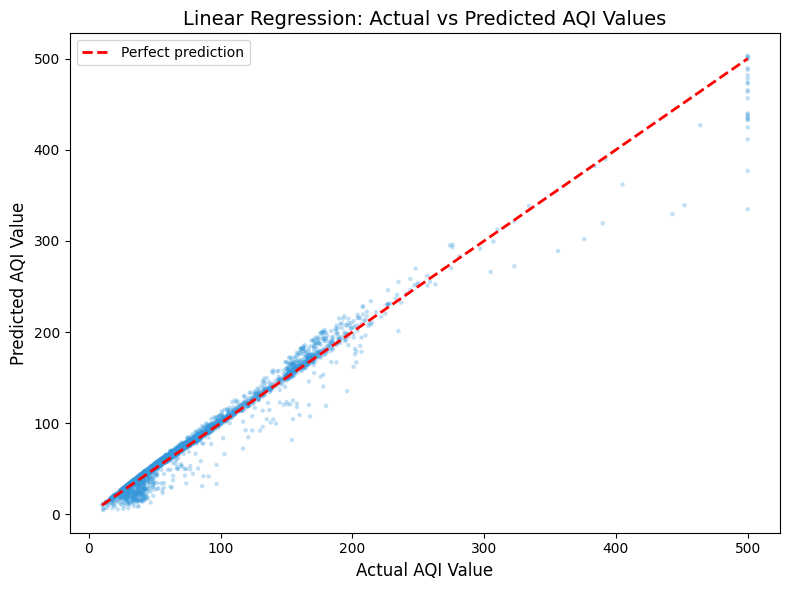

In [ ]:
plt.figure(figsize=(8,6 ))
plt.scatter(y_test,y_pred_lr,alpha=0.3,color='#3498db',edgecolors='none',s=10)#scatter of actual vs predicted
plt.plot([y_test.min() ,y_test.max()] ,[y_test.min() ,y_test.max()], 'r--',  linewidth=2, label='Perfect prediction')#diagonal line = perfect prediction
plt.xlabel('Actual AQI Value',fontsize=12)

plt.ylabel('Predicted AQI Value',fontsize=12)
plt.title( 'Linear Regression: Actual vs Predicted AQI Values',fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance (Coefficients)

In Linear Regression, the model coefficients tell us how much each pollutant contributes to the predicted AQI Value. A larger absolute coefficient means a stronger influence.

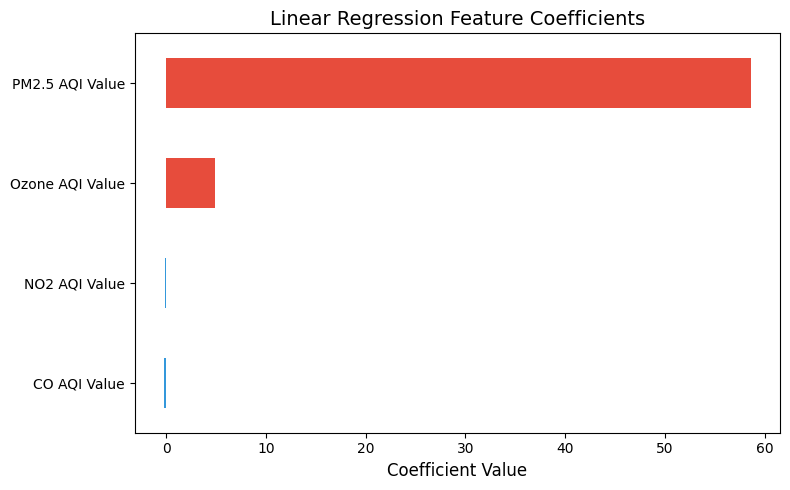

Feature Coefficients:
CO AQI Value       -0.1956
Ozone AQI Value     4.8639
NO2 AQI Value      -0.1472
PM2.5 AQI Value    58.5889
dtype: float64


In [ ]:
coefficients=pd.Series(lr_model.coef_,index=X.columns)#extract model coefficients for each feature

plt.figure(figsize=(8,5))
coefficients.sort_values().plot(kind='barh',color=['#e74c3c' if c > 0 else '#3498db' for c in coefficients.sort_values()])#positive coefficients in red, negative in blue
plt.title('Linear Regression Feature Coefficients',fontsize=14)
plt.xlabel('Coefficient Value',fontsize=12)
plt.tight_layout()
plt.show()
print("Feature Coefficients:")
print( coefficients.round(4))

### Interpretation

The Linear Regression model provides our baseline for AQI Value prediction. The R² score tells us how much of the variation in AQI values across cities the model can explain using pollutant readings. PM2.5 is expected to have the largest coefficient given its dominant correlation with AQI, as identified in the EDA section.

---
## Step 9: Top 10 Most Polluted Countries

To add a broader geographic perspective, we reload the original dataset and identify the ten countries with the highest average AQI values.

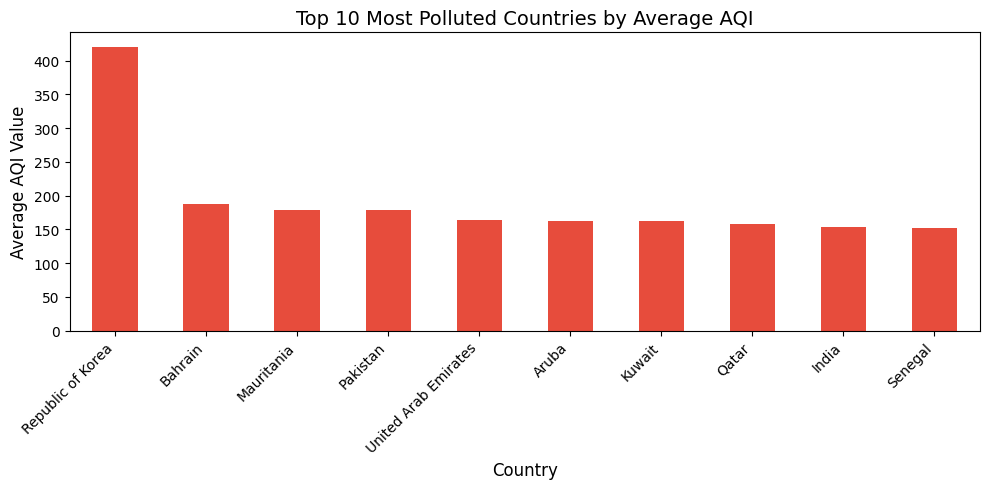

Top 10 Most Polluted Countries:
Country
Republic of Korea       421.00
Bahrain                 188.00
Mauritania              179.00
Pakistan                178.79
United Arab Emirates    163.67
Aruba                   163.00
Kuwait                  162.00
Qatar                   157.50
India                   152.96
Senegal                 152.42
Name: AQI Value, dtype: float64


In [ ]:
df_country=pd.read_csv('global_air_pollution_dataset.csv').dropna(subset=['Country'])#reload original dataset to use the Country column
top_countries =df_country.groupby('Country')['AQI Value'].mean().sort_values(ascending=False).head(10)#average AQI per country, top 10
top_countries.plot(kind= 'bar',figsize=( 10,5) , color='#e74c3c')
plt.title('Top 10 Most Polluted Countries by Average AQI',fontsize=14)
plt.xlabel( 'Country',fontsize=12)
plt.ylabel('Average AQI Value', fontsize=12)
plt.xticks( rotation=45, ha='right')#rotate labels to prevent overlap
plt.tight_layout()
plt.show()
print("Top 10 Most Polluted Countries:")
print( top_countries.round(2))

This chart identifies which countries have the highest average air pollution levels in the dataset, providing a geographic dimension to the analysis and highlighting where intervention is most urgently needed.

---
## Step 10: Random Forest Regressor

Linear Regression assumes a straight-line relationship between the pollutants and the AQI Value. To see whether a non-linear model can capture the data more accurately, we now train a Random Forest Regressor on the same features and target, using the same train/test split. Random Forest builds many decision trees and averages their predictions, which often handles non-linear patterns and outliers well.

We train the Random Forest model on the same scaled training data we used for Linear Regression, so the comparison is fair. Tree-based models do not strictly require scaling, but using the same inputs keeps the experiment consistent.

In [ ]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)#100 trees 
rf_model.fit( X_train_scaled,y_train)#train the model on the scaled training data
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


We now use the trained Random Forest to predict AQI values on the test set, then compare them with the actual values.

In [ ]:
y_pred_rf = rf_model.predict(X_test_scaled)#predict AQI values using the random forest model
print("Predictions completed.")
print(f"Sample predictions: {y_pred_rf[:5].round(2)}")#first 5 predictions
print(f"Actual values:{y_test[:5].values}")#first 5 actual values for comparison

Predictions completed.
Sample predictions: [37. 41. 65. 53. 34.]
Actual values:      [37 41 65 53 34]


We evaluate the Random Forest model with the same three regression metrics used for Linear Regression — MAE, RMSE, and R² — so the two models can be compared directly.

In [102]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)#average absolute prediction error
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))#penalizes larger errors more heavily
r2_rf = r2_score(y_test, y_pred_rf)#proportion of variance explained by the model
print("Random Forest Performance:")
print(f"MAE:  {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²:   {r2_rf:.4f}")

Random Forest Performance:
MAE:  0.36
RMSE: 3.91
R²:   0.9961


### Visualising Predictions vs Actual Values (Random Forest)

As before, points close to the diagonal red line mean accurate predictions.

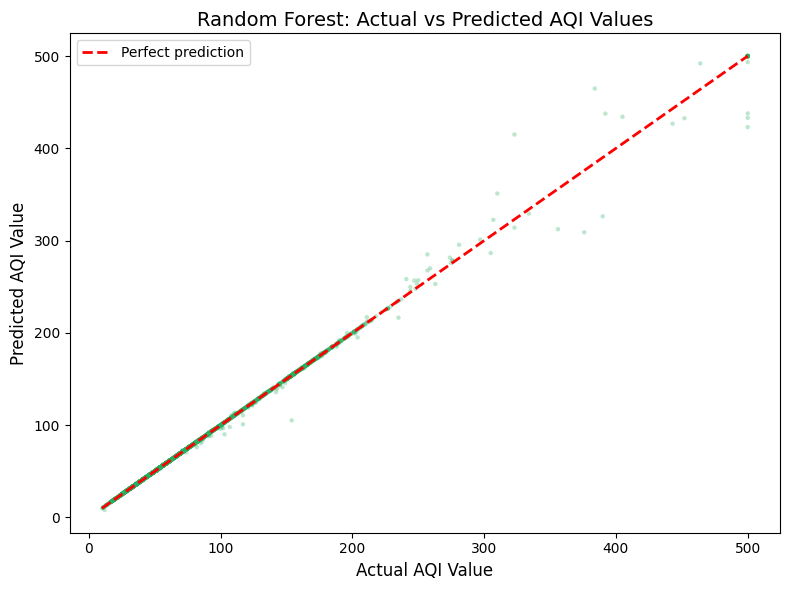

In [ ]:
plt.figure(figsize=( 8,6))
plt.scatter(y_test , y_pred_rf,alpha=0.3,color='#27ae60',edgecolors='none',s=10)#scatter of actual vs predicted
plt.plot([y_test.min() , y_test.max()],[ y_test.min(),y_test.max() ],'r--',linewidth=2,label='Perfect prediction')#diagonal line =perfect prediction
plt.xlabel('Actual AQI Value',fontsize=12 )
plt.ylabel('Predicted AQI Value', fontsize =12)
plt.title('Random Forest: Actual vs Predicted AQI Values', fontsize= 14)
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance (Random Forest)

Random Forest provides a feature importance score for each input. The score reflects how much each pollutant contributes to reducing prediction error across all trees in the forest. A larger value means the pollutant plays a bigger role in predicting AQI.

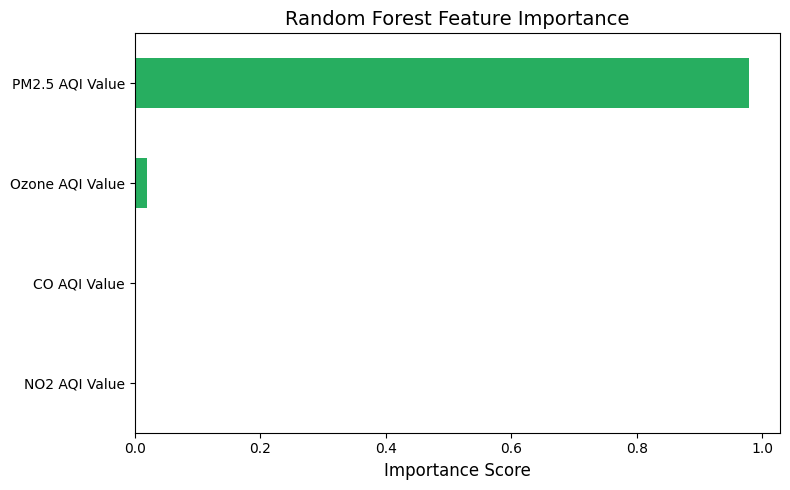

Feature Importances:
PM2.5 AQI Value    0.9794
Ozone AQI Value    0.0191
CO AQI Value       0.0010
NO2 AQI Value      0.0005
dtype: float64


In [ ]:
importances = pd.Series(rf_model.feature_importances_,index=X.columns)#extract feature importances from the trained model
plt.figure(figsize=(8,5))
importances.sort_values().plot(kind='barh',color='#27ae60')
plt.title('Random Forest Feature Importance',fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()

print("Feature Importances:")
print( importances.sort_values(ascending=False).round(4))#round to 4 decimal places

### Interpretation

PM2.5 is again the dominant feature, which matches what we saw in both the EDA correlation heatmap and the Linear Regression coefficients. The fact that two very different model families agree on PM2.5's importance gives us confidence that this is a real pattern in the data and not a quirk of one model.

---
## Step 11: Model Comparison

We now place the two models side by side using the same three metrics. This makes it easy to see which model performs better at predicting AQI Value on unseen data.

In [ ]:
comparison = pd.DataFrame({'Linear Regression': [mae_lr, rmse_lr, r2_lr],'Random Forest': [mae_rf, rmse_rf, r2_rf]}, index=[ 'MAE', 'RMSE', 'R²']).round(4)#comparison table for both models
print("=" * 55)#for visual purposes
print("Model Comparison: Linear Regression vs Random Forest")
print("=" * 55)
print( comparison)
print("=" * 55)

Model Comparison: Linear Regression vs Random Forest
      Linear Regression  Random Forest
MAE              5.1027         0.3636
RMSE            10.0895         3.9084
R²               0.9738         0.9961


### Visual Comparison

To make the comparison easier to read, we plot the metrics as a grouped bar chart. MAE and RMSE are error metrics, so lower is better. R² shows how much variance in AQI is explained, so higher is better.

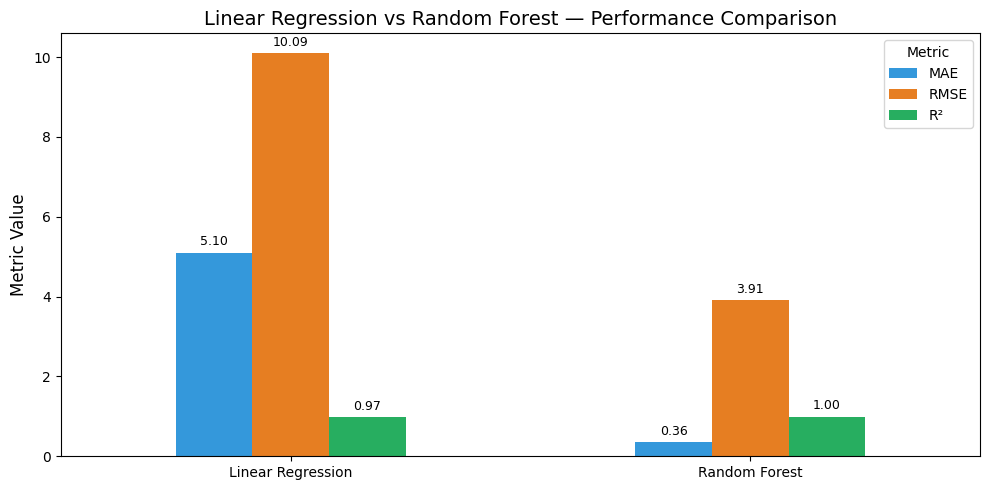

In [ ]:
ax = comparison.T.plot(kind='bar',figsize=( 10,5) ,color=[ '#3498db','#e67e22','#27ae60'])#grouped bar chart comparing both models
plt.title('Linear Regression vs Random Forest — Performance Comparison',fontsize=14)
plt.ylabel('Metric Value',fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Metric')
for container in ax.containers:
    ax.bar_label(container,fmt='%.2f',padding=3,fontsize=9)#add numeric value on top of each bar

plt.tight_layout()
plt.show()

### Discussion

Both models perform well, but Random Forest produces lower MAE and RMSE and a higher R² than Linear Regression. This suggests that the relationship between the pollutants and the overall AQI Value is not perfectly linear and that the tree-based model is able to capture small non-linear effects that the linear model misses. That said, Linear Regression already explains most of the variance and is far simpler to interpret, which makes it a strong baseline for this problem.

---
## Step 12: Export Model for the Interactive UI

To let a user try the model from a simple web interface, we save the trained Random Forest model and the fitted `StandardScaler` to disk using `joblib`. The Streamlit app (`app.py`) loads these two files, scales the user's inputs the same way the training data was scaled, and returns a predicted AQI Value.

**Important:** the cell below must be run before launching the Streamlit app, otherwise the app will not find `rf_model.joblib` and `scaler.joblib`.

In [ ]:
joblib.dump(rf_model,'rf_model.joblib')#save the trained random forest model to disk
joblib.dump(scaler,'scaler.joblib')#save the fitted scaler so the app uses the same scaling

print("Saved 'rf_model.joblib' and 'scaler.joblib' to the project folder.")
print("Run the UI from a terminal with:  streamlit run app.py")

Saved 'rf_model.joblib' and 'scaler.joblib' to the project folder.
Run the UI from a terminal with:  streamlit run app.py


---
## Appendix: Memory Optimization

By default, pandas reads all integer columns as `int64` and all string columns as the generic `object` type, which uses more memory than necessary. For this dataset, the AQI value columns easily fit into smaller integer types, and the AQI category columns only contain a handful of repeated labels, which makes them ideal candidates for the `category` dtype.

Below we measure the memory footprint of the original dataset, then apply the following optimizations and measure again:
- Convert AQI value columns from `int64` to `int16` (their values fit comfortably within −32,768 to 32,767).
- Convert AQI category columns from `object` to `category`.

This appendix is referenced in the report's Appendix section.

In [ ]:
df_mem = pd.read_csv('global_air_pollution_dataset.csv')#reload original dataset to measure memory before any changes

mem_before = df_mem.memory_usage(deep=True).sum() / 1024**2#deep=True counts actual string contents not just pointers
print(f"Memory usage BEFORE optimization: {mem_before:.2f} MB")
print("\nDtypes before optimization:")
print( df_mem.dtypes)

Memory usage BEFORE optimization: 10.89 MB

Dtypes before optimization:
Country               object
City                  object
AQI Value              int64
AQI Category          object
CO AQI Value           int64
CO AQI Category       object
Ozone AQI Value        int64
Ozone AQI Category    object
NO2 AQI Value          int64
NO2 AQI Category      object
PM2.5 AQI Value        int64
PM2.5 AQI Category    object
dtype: object


In [ ]:
int_cols=[ 'AQI Value','CO AQI Value', 'Ozone AQI Value','NO2 AQI Value' ,'PM2.5 AQI Value']
for col in int_cols:
    df_mem[col] =df_mem[col].astype('int16')#downcast from int64 to int16, values fit within -32768 to 32767

cat_cols=['Country','AQI Category','CO AQI Category' ,'Ozone AQI Category','NO2 AQI Category','PM2.5 AQI Category']
for col in cat_cols:
    df_mem[col ]=df_mem[col].astype( 'category')#category dtype stores repeated strings as integer codes, more compact than object

mem_after =df_mem.memory_usage(deep=True ).sum() / 1024**2
print(f"Memory usage AFTER optimization: {mem_after:.2f} MB")
print(f"Reduction: { mem_before - mem_after:.2f} MB ({(1 - mem_after / mem_before) * 100:.1f}%)")
print("\nDtypes after optimization:" )
print( df_mem.dtypes)

Memory usage AFTER optimization:  1.87 MB
Reduction: 9.03 MB (82.9%)

Dtypes after optimization:
Country               category
City                    object
AQI Value                int16
AQI Category          category
CO AQI Value             int16
CO AQI Category       category
Ozone AQI Value          int16
Ozone AQI Category    category
NO2 AQI Value            int16
NO2 AQI Category      category
PM2.5 AQI Value          int16
PM2.5 AQI Category    category
dtype: object


### Summary of Optimizations

| Change | Reason |
|---|---|
| `AQI Value`, `CO AQI Value`, `Ozone AQI Value`, `NO2 AQI Value`, `PM2.5 AQI Value`: `int64` → `int16` | All values are non-negative integers under 1,000, so they fit in `int16` (range −32,768 to 32,767). `int16` uses 2 bytes per value instead of 8. |
| `Country`, `AQI Category`, `CO AQI Category`, `Ozone AQI Category`, `NO2 AQI Category`, `PM2.5 AQI Category`: `object` → `category` | These columns repeat the same small set of labels thousands of times. The `category` dtype stores each unique label once and uses small integer codes for the rows. |

These changes reduce the in-memory size of the dataset substantially without losing any information, and they also speed up groupby and filtering operations on the categorical columns.